# **Grover's search algorithm**

**Installation of required packages**

In [1]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.3 MB/s eta 0:00:00


In [2]:
pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 18.7 MB/s eta 0:00:00


In [3]:
pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=1618d173c235572f0845b195387b62895dc66334c5c4fac3bd83aac822d945b2
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [4]:
pip install qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.4/377.4 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 4.5 MB/s eta 0:00:00


In [2]:
#initialization
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# importing Qiskit
from qiskit_aer import Aer
# from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit, transpile, ClassicalRegister, QuantumRegister

from qiskit.quantum_info.operators import Operator

# import basic plot tools
from qiskit.visualization import *

In [3]:
def inversion_about_average(circuit, register):
    """Apply inversion about the average step of Grover's algorithm."""
    circuit.h(register)
    circuit.x(register)
    circuit.barrier()
    circuit.h(register[2])
    circuit.ccx(register[0], register[1], register[2])
    circuit.h(register[2])
    circuit.barrier()
    circuit.x(register)
    circuit.h(register)

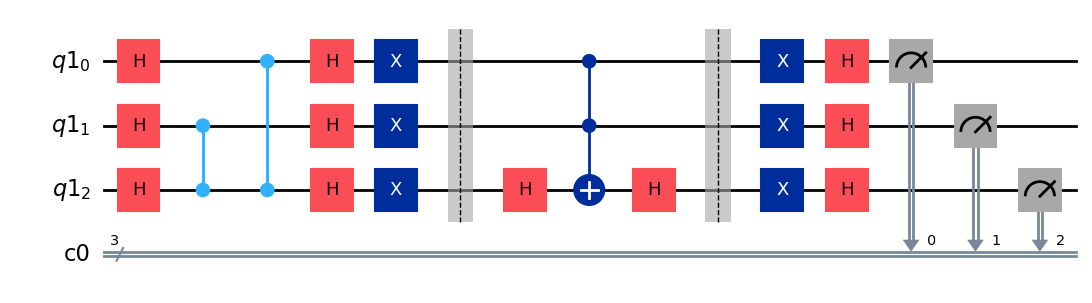

In [4]:
qr = QuantumRegister(3)
cr = ClassicalRegister(3)

groverCircuit = QuantumCircuit(qr,cr)
groverCircuit.h(qr)

#mark state '101' and '110'
groverCircuit.cz(1,2)
groverCircuit.cz(0,2)


inversion_about_average(groverCircuit, qr)

groverCircuit.measure(qr,cr)
groverCircuit.draw(output="mpl")

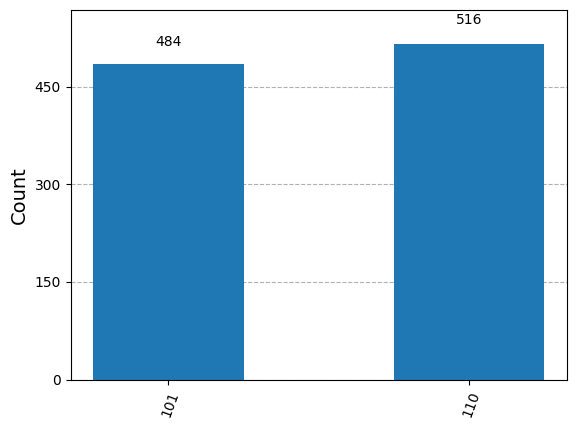

In [7]:
backend = Aer.get_backend('qasm_simulator')
shots = 1024
new_circuit = transpile(groverCircuit, backend)
job = backend.run(new_circuit, shots = 1000)
counts = job.result().get_counts() # we run the simulation and get the counts
plot_histogram(counts) # let us plot a histogram to see the possible outcomes and corresponding probabilities

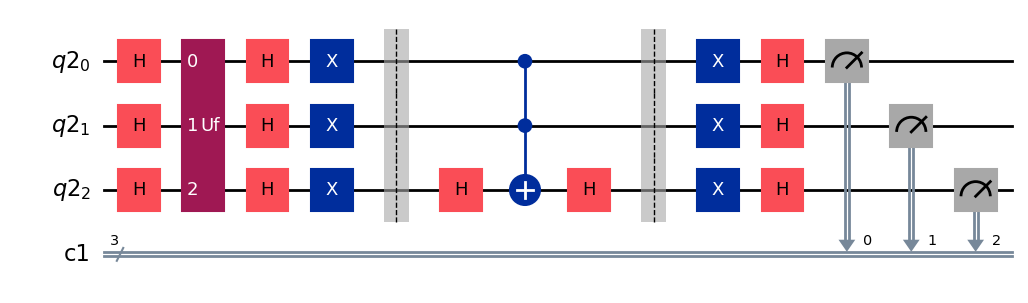

In [8]:
qr = QuantumRegister(3)
cr = ClassicalRegister(3)

groverCircuit = QuantumCircuit(qr,cr)
groverCircuit.h(qr)

#marked "00" as target state.
uf = Operator([
    [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]])

groverCircuit.unitary(uf, [qr[0], qr[1], qr[2]], label='Uf')
inversion_about_average(groverCircuit, qr)

groverCircuit.measure(qr,cr)
groverCircuit.draw(output="mpl")

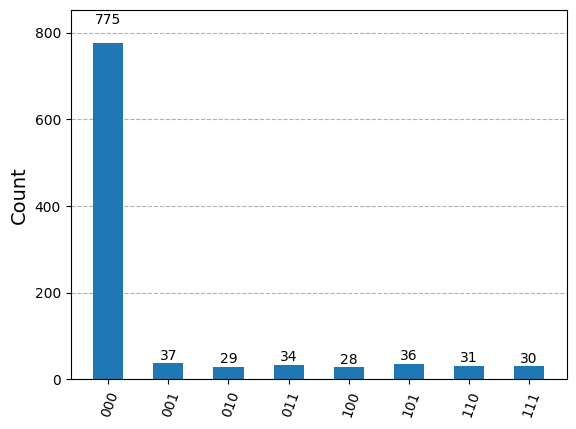

In [9]:
backend = Aer.get_backend('qasm_simulator')
shots = 1024
new_circuit = transpile(groverCircuit, backend)
job = backend.run(new_circuit, shots = 1000)
counts = job.result().get_counts() # we run the simulation and get the counts
plot_histogram(counts) # let us plot a histogram to see the possible outcomes and corresponding probabilities

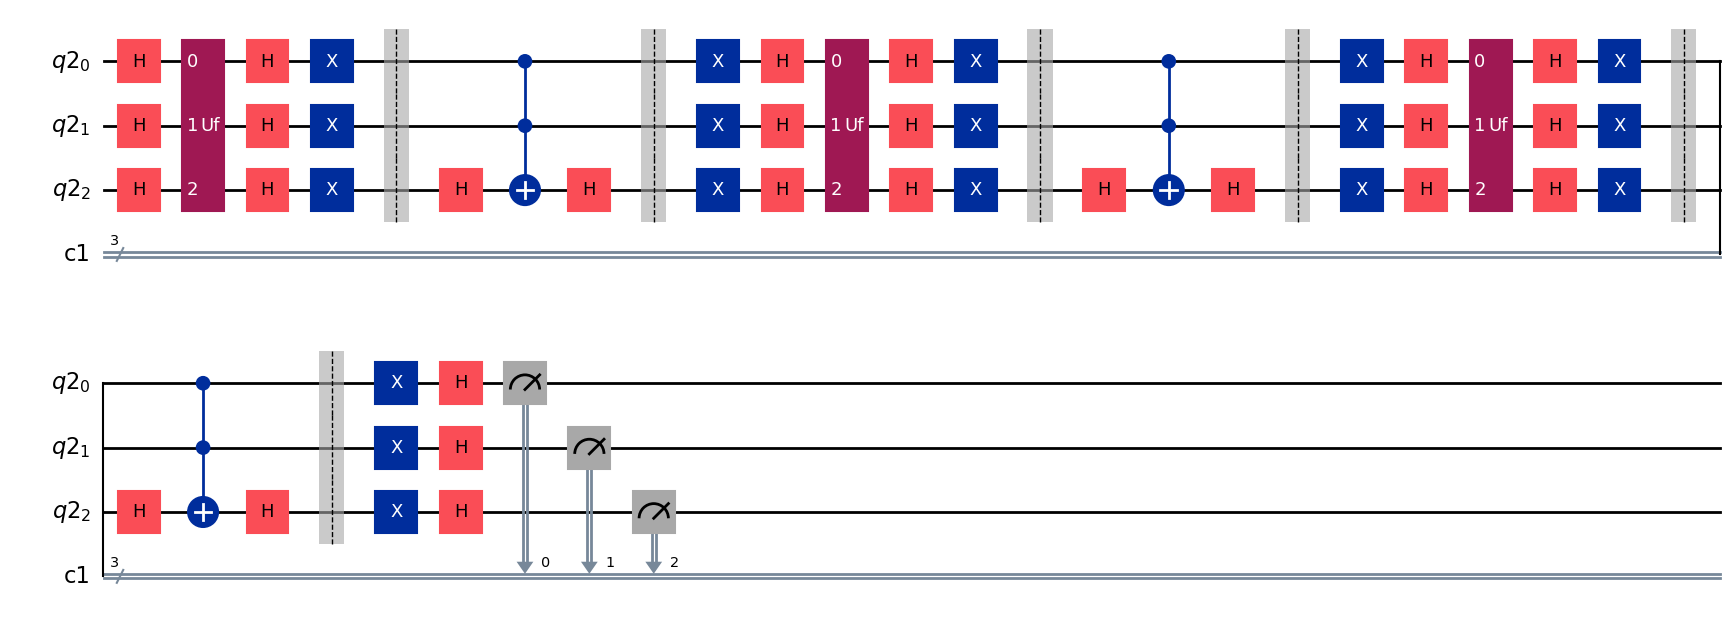

In [10]:
groverCircuit2 = QuantumCircuit(qr,cr)
groverCircuit2.h(qr)

#marked "00" as target state.
uf = Operator([
    [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]])

#Grover iteration 1st
groverCircuit2.unitary(uf, [qr[0], qr[1], qr[2]], label='Uf')
inversion_about_average(groverCircuit2, qr)
#Grover iteration 2nd
groverCircuit2.unitary(uf, [qr[0], qr[1], qr[2]], label='Uf')
inversion_about_average(groverCircuit2, qr)
#Grover iteration 3rd
groverCircuit2.unitary(uf, [qr[0], qr[1], qr[2]], label='Uf')
inversion_about_average(groverCircuit2, qr)

groverCircuit2.measure(qr,cr)
groverCircuit2.draw(output="mpl")

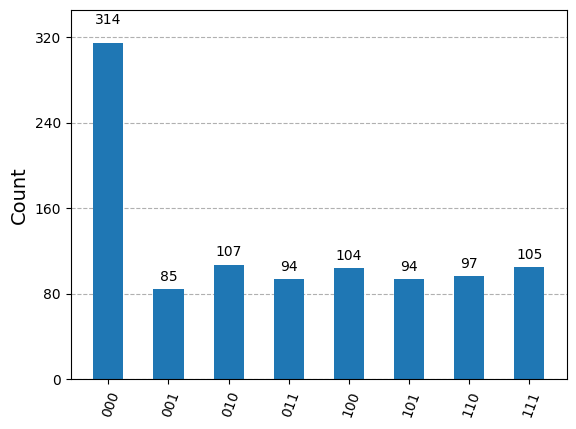

In [11]:
backend = Aer.get_backend('qasm_simulator')
shots = 1024
new_circuit = transpile(groverCircuit2, backend)
job = backend.run(new_circuit, shots = 1000)
counts = job.result().get_counts() # we run the simulation and get the counts
plot_histogram(counts) # let us plot a histogram to see the possible outcomes and corresponding probabilities

# Question

*Answer the questions in this markdown cell*

What is the complexity of grover's algorithm? Answer in term of $N$.  
Your answer: $\mathcal{O}(???)$

How many interation of Grover's algorithm do you need from calculation?  
Your answer:

## After Lab

How many interation of Grover's algorithm you found it to give best solution?  
Your answer:

# Your Task

Write Grover's algorithm for a 4 qubit circuit that marks 1100 and 0101

Note: You will have to modify `inversion_about_average` to make it support any number of qubits

In [13]:
def inversion_about_average2(circuit, register):
    """Apply inversion about the average step of Grover's algorithm."""
    circuit.h(register)
    circuit.x(register)
    circuit.barrier()
    circuit.h(register[0])
    circuit.mcx([register[3], register[2], register[1]], register[0])
    circuit.h(register[0])
    circuit.barrier()
    circuit.x(register)
    circuit.h(register)

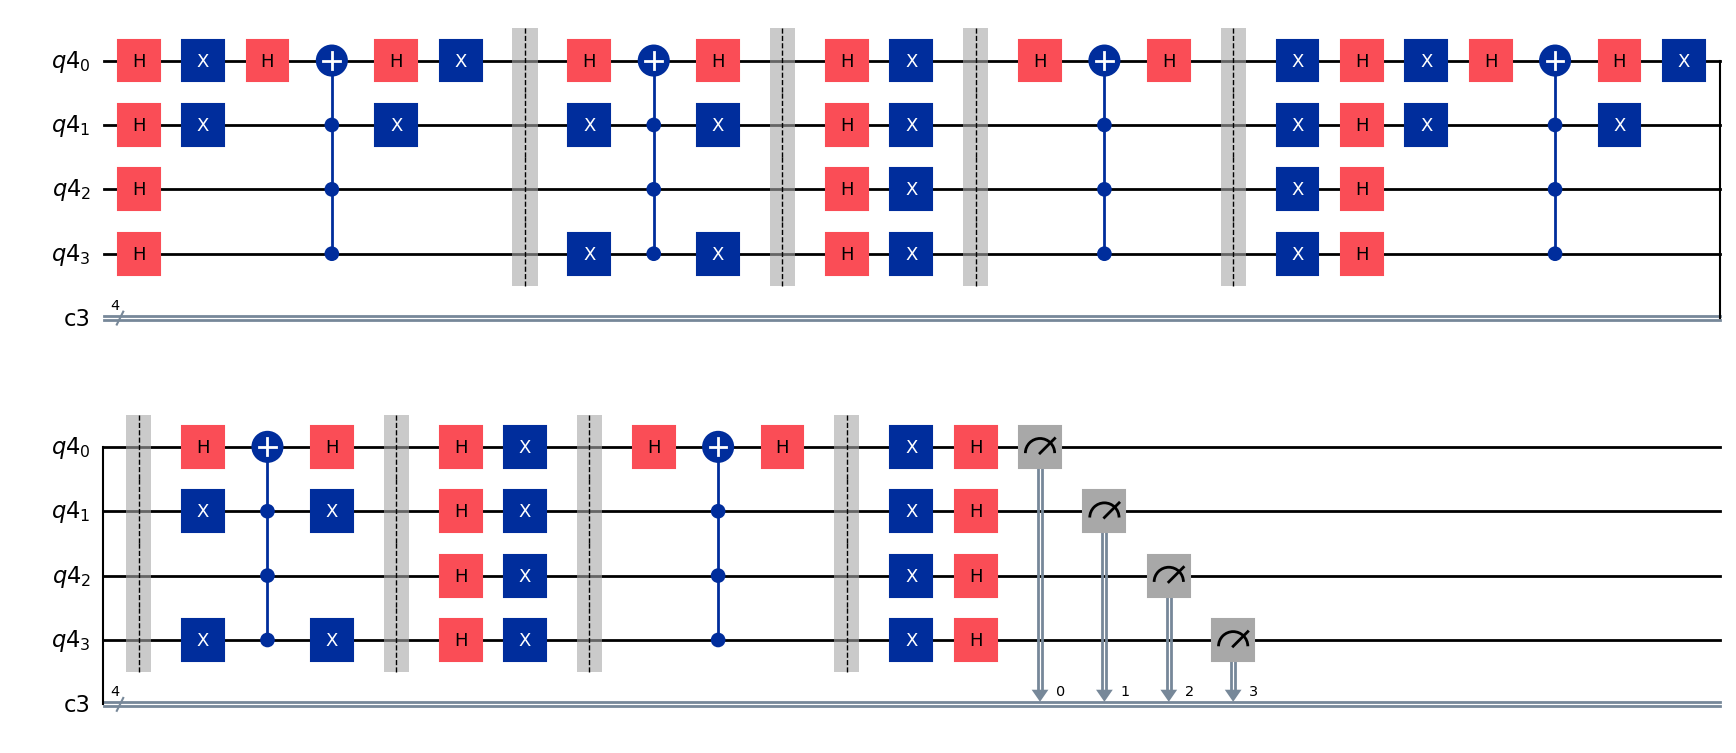

In [14]:
qr = QuantumRegister(4)
cr = ClassicalRegister(4)

groverCircuit3 = QuantumCircuit(qr,cr)
groverCircuit3.h(qr)

#mark state '1100'
#Grover ietration 1st
groverCircuit3.x(0)
groverCircuit3.x(1)
groverCircuit3.h(0)
groverCircuit3.mcx([3,2,1],0)
groverCircuit3.h(0)
groverCircuit3.x(1)
groverCircuit3.x(0)
groverCircuit3.barrier()
#mark state '0101'
groverCircuit3.x(1)
groverCircuit3.x(3)
groverCircuit3.h(0)
groverCircuit3.mcx([3,2,1],0)
groverCircuit3.h(0)
groverCircuit3.x(3)
groverCircuit3.x(1)

groverCircuit3.barrier()
inversion_about_average2(groverCircuit3, qr)

#Grover ietration 2nd
groverCircuit3.x(0)
groverCircuit3.x(1)
groverCircuit3.h(0)
groverCircuit3.mcx([3,2,1],0)
groverCircuit3.h(0)
groverCircuit3.x(1)
groverCircuit3.x(0)
groverCircuit3.barrier()
#mark state '0101'
groverCircuit3.x(1)
groverCircuit3.x(3)
groverCircuit3.h(0)
groverCircuit3.mcx([3,2,1],0)
groverCircuit3.h(0)
groverCircuit3.x(3)
groverCircuit3.x(1)

groverCircuit3.barrier()
inversion_about_average2(groverCircuit3, qr)



groverCircuit3.measure(qr,cr)
groverCircuit3.draw(output="mpl")

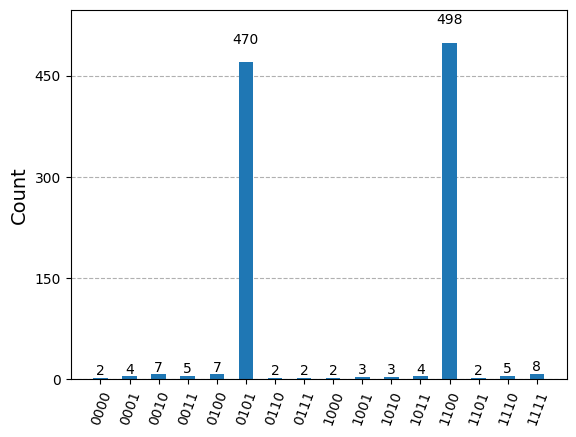

In [19]:
backend = Aer.get_backend('qasm_simulator')
shots = 1024
new_circuit = transpile(groverCircuit3, backend)
job = backend.run(new_circuit)
counts = job.result().get_counts() # we run the simulation and get the counts
plot_histogram(counts) # let us plot a histogram to see the possible outcomes and corresponding probabilities